In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
data = 'telco_dataset.csv'
df = pd.read_csv(data)

df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_cols = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_cols:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [3]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']



In [4]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [5]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8055358410220014)

In [6]:
len(y_val)

1409

In [7]:
(y_val == churn_decision).sum()

np.int64(1135)

In [8]:
threshold = np.linspace(0, 1, 21)
scores = []
for t in threshold:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).mean()
    print('%.2f %.3f' % (t, score))
    scores.append(score)


0.00 0.274
0.05 0.508
0.10 0.605
0.15 0.664
0.20 0.705
0.25 0.738
0.30 0.759
0.35 0.767
0.40 0.781
0.45 0.793
0.50 0.806
0.55 0.804
0.60 0.800
0.65 0.787
0.70 0.766
0.75 0.742
0.80 0.729
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


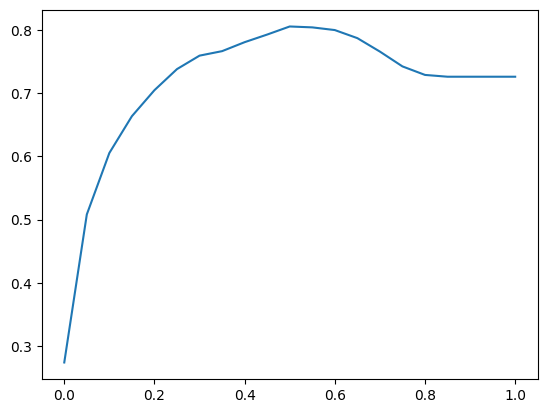

In [9]:
plt.plot(threshold, scores)

In [10]:
from sklearn.metrics import accuracy_score

In [11]:
thresholds = np.linspace(0, 1, 21)
scores = []
for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('%.2f %.3f' % (t, score))
    scores.append(score)


0.00 0.274
0.05 0.508
0.10 0.605
0.15 0.664
0.20 0.705
0.25 0.738
0.30 0.759
0.35 0.767
0.40 0.781
0.45 0.793
0.50 0.806
0.55 0.804
0.60 0.800
0.65 0.787
0.70 0.766
0.75 0.742
0.80 0.729
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


In [12]:
from collections import Counter

Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [13]:
(1 - y_val).mean()

np.float64(0.7260468417317246)

### Confusion matrix (check the whiteboard)

In [14]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

threshold = 0.5

predict_positive = (y_pred >= threshold)
predict_negative = (y_pred < threshold)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

confusion_matrix

array([[923, 100],
       [174, 212]])

In [15]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.66, 0.07],
       [0.12, 0.15]])

### Precision and recall

In [16]:
precision = tp / (tp + fp)
precision

np.float64(0.6794871794871795)

In [17]:
tp + fp

np.int64(312)

In [18]:
tp

np.int64(212)

In [19]:
recall = tp / (tp + fn)
recall

np.float64(0.5492227979274611)

## ROC Curves

### TPR and FPR

In [20]:
tpr = tp / (tp + fn)
tpr

np.float64(0.5492227979274611)

In [22]:
fpr = fp / (tn + fp)
fpr

np.float64(0.09775171065493646)

In [23]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, tn, fn))

In [30]:
columns = ['threshold', 'true_positive', 'false_positive', 'true_negative', 'false_negative']
df_scores = pd.DataFrame(scores, columns =columns)
df_scores['tpr'] = df_scores.true_positive / (df_scores.true_positive + df_scores.false_negative)
df_scores['fpr'] = df_scores.false_positive / (df_scores.true_negative + df_scores.false_positive)
df_scores

,threshold,true_positive,false_positive,true_negative,false_negative,tpr,fpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,385,901,122,1,0.997409,0.880743
2,0.02,383,808,215,3,0.992228,0.789834
3,0.03,382,753,270,4,0.989637,0.736070
4,0.04,382,714,309,4,0.989637,0.697947
...,...,...,...,...,...,...,...
96,0.96,0,0,1023,386,0.000000,0.000000
97,0.97,0,0,1023,386,0.000000,0.000000
98,0.98,0,0,1023,386,0.000000,0.000000
99,0.99,0,0,1023,386,0.000000,0.000000


In [31]:
df_scores[::10]

,threshold,true_positive,false_positive,true_negative,false_negative,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,367,537,486,19,0.950777,0.524927
20,0.2,337,367,656,49,0.873057,0.358749
30,0.3,292,245,778,94,0.756477,0.239492
40,0.4,252,175,848,134,0.652850,0.171065
50,0.5,212,100,923,174,0.549223,0.097752
60,0.6,155,51,972,231,0.401554,0.049853
70,0.7,69,13,1010,317,0.178756,0.012708
80,0.8,4,0,1023,382,0.010363,0.000000
90,0.9,0,0,1023,386,0.000000,0.000000


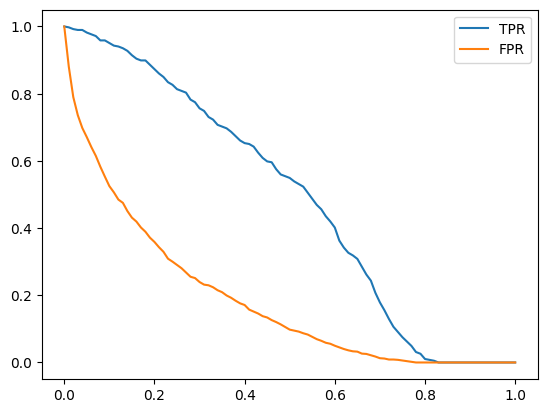

In [33]:
plt.plot(df_scores.threshold, df_scores.tpr, label='TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label='FPR')
plt.legend()

In [35]:
y_rand = np.random.uniform(0, 1, size=len(y_val))

y_rand.round(3)

array([0.949, 0.666, 0.178, ..., 0.197, 0.28 , 0.082], shape=(1409,))

In [36]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.49467707594038324)

In [37]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, tn, fn))
    columns = ['threshold', 'true_positive', 'false_positive', 'true_negative', 'false_negative']
    df_scores = pd.DataFrame(scores, columns =columns)
    df_scores['tpr'] = df_scores.true_positive / (df_scores.true_positive + df_scores.false_negative)
    df_scores['fpr'] = df_scores.false_positive / (df_scores.true_negative + df_scores.false_positive)
    return df_scores
    

In [38]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand[::10]

,threshold,true_positive,false_positive,true_negative,false_negative,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,346,918,105,40,0.896373,0.897361
20,0.2,315,839,184,71,0.816062,0.820137
30,0.3,275,730,293,111,0.712435,0.713587
40,0.4,227,617,406,159,0.588083,0.603128
50,0.5,187,513,510,199,0.484456,0.501466
60,0.6,154,410,613,232,0.398964,0.400782
70,0.7,118,315,708,268,0.305699,0.307918
80,0.8,83,210,813,303,0.215026,0.205279
90,0.9,50,101,922,336,0.129534,0.098729


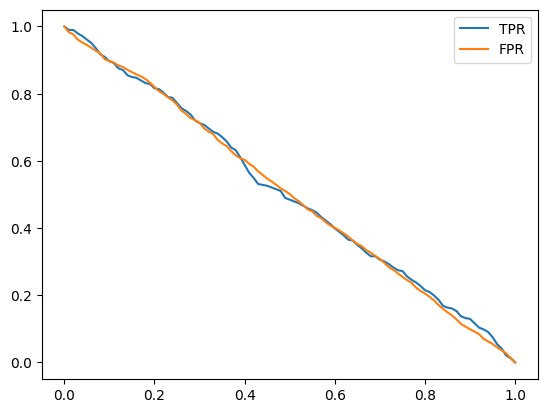

In [40]:
plt.plot(df_rand.threshold, df_rand.tpr, label='TPR')
plt.plot(df_rand.threshold, df_rand.fpr, label='FPR')
plt.legend()

In [41]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()

y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [42]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [43]:
accuracy_score(y_ideal, y_ideal_pred >= 0.726)

1.0

In [44]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,true_positive,false_positive,true_negative,false_negative,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,141,0,1.000000,0.862170
20,0.2,386,741,282,0,1.000000,0.724340
30,0.3,386,600,423,0,1.000000,0.586510
40,0.4,386,459,564,0,1.000000,0.448680
50,0.5,386,319,704,0,1.000000,0.311828
60,0.6,386,178,845,0,1.000000,0.173998
70,0.7,386,37,986,0,1.000000,0.036168
80,0.8,282,0,1023,104,0.730570,0.000000
90,0.9,141,0,1023,245,0.365285,0.000000


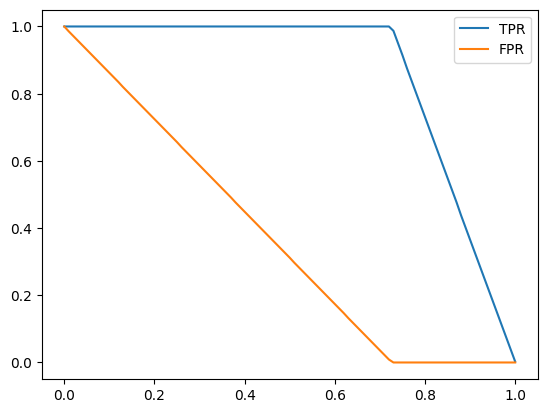

In [45]:
plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR')
plt.legend()